### Supernova distances and redshifts: Hubble diagram for Type Ia supernovae
Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

Let's recall the definition of magnitude and the distance modulus:
$$ \mu = m-M = 5\,\text{log}_{10}\biggl(\frac{d_L}{10\,\text{pc}}\biggr)$$

#### Libraries

In [1]:
# ! pip install astroML --upgrade

In [2]:
# ! pip install PyMC3

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from astroML.datasets import generate_mu_z
from astroML.linear_model import LinearRegression, PolynomialRegression
import matplotlib.pyplot as plt
import numpy as np

#### Exercize

**Tasks**
1. First, explore fitting this data with the tecniques we have seen.
Start from linear regression and polynomial regression.
For the case of polynomial regression, just fit many of them for now.
2. Let's bet based on intuition! Which fit is the best?
In what cases are you underfitting the data?
In what cases are you overfitting the data?
Now split the data into training and validation sets.
Implement a cross-validation procedure.
Pick the best!
Does it agree with our bets?

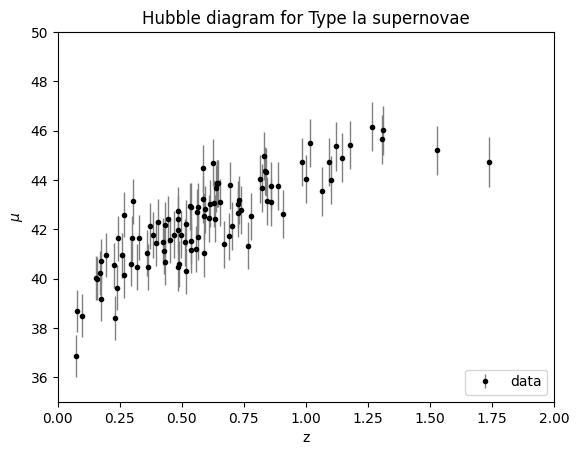

In [4]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("Hubble diagram for Type Ia supernovae")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

In [5]:
# remember sklearn requires format (n_samples, n_features)
X = np.array([z_sample]).T
y = np.array(mu_sample)
y_err = np.array(dmu)

In [6]:
print(X.shape)
print(y.shape)

(100, 1)
(100,)


In [7]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.25, random_state=42)

##### Linear fit

In [8]:
LRmodel = LinearRegression()
LRmodel.fit(X_train, y_train, y_err[train_idx])
y_pred_train = LRmodel.predict(X_train)
y_pred_test = LRmodel.predict(X_test)

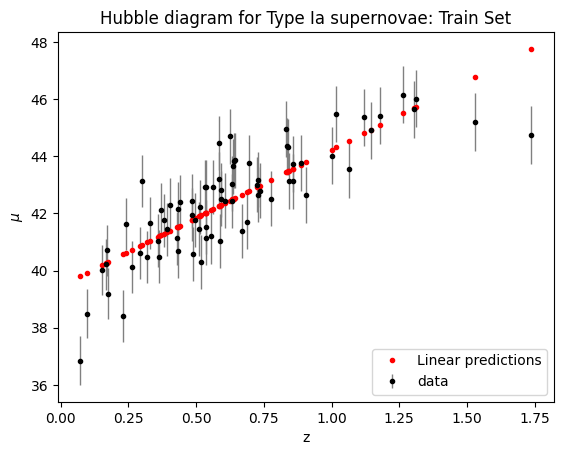

In [9]:
plt.errorbar(X_train, y_train, y_err[train_idx], fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(X_train, y_pred_train, '.r', label='Linear predictions')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("Hubble diagram for Type Ia supernovae: Train Set")
plt.legend(loc='lower right')
plt.show()

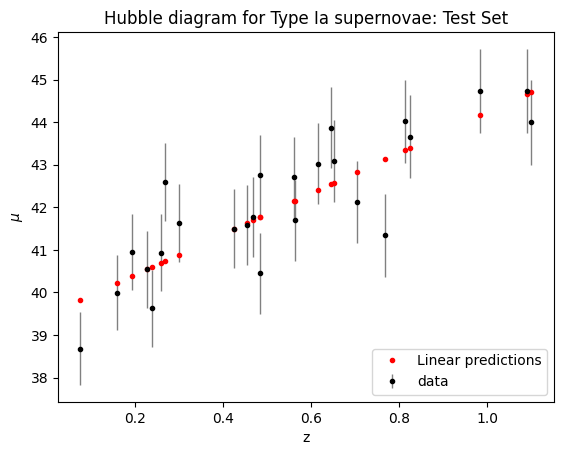

In [10]:
plt.errorbar(X_test, y_test, y_err[test_idx], fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(X_test, y_pred_test, '.r', label='Linear predictions')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("Hubble diagram for Type Ia supernovae: Test Set")
plt.legend(loc='lower right')
plt.show()

In [11]:
print(np.array([y_test, y_pred_test]).T)

[[43.87095979 42.53683948]
 [38.68032347 39.82135878]
 [41.33982132 43.12845946]
 [42.7005633  42.1398588 ]
 [43.02875083 42.39683059]
 [44.73434708 44.6727782 ]
 [40.95384945 40.38428539]
 [42.75984556 41.77084892]
 [41.50167538 41.48647298]
 [41.6361725  40.88853774]
 [44.02200845 43.34778555]
 [44.73365314 44.1613973 ]
 [40.53942813 40.54065697]
 [40.93682681 40.69989126]
 [42.58715034 40.73595223]
 [43.66317337 43.39685926]
 [41.78066489 41.69736952]
 [41.69520148 42.1500938 ]
 [42.12960007 42.81986184]
 [40.44836116 41.76820665]
 [43.99305977 44.71575383]
 [43.08992651 42.57406249]
 [41.57489699 41.6268337 ]
 [39.99757862 40.21925324]
 [39.62962917 40.59585062]]


##### Polynomial fit

In [12]:
vec_degree = np.arange(1,10,1)
vec_coef = []

for d in vec_degree:
  PRmodel = PolynomialRegression(d) # fit d-degree polynomial
  PRmodel.fit(X, y, y_err)

  # np.poly1d vuole i coefficienti in ordine decrescente di potenza
  coef = PRmodel.coef_
  coef = coef[::-1]
  vec_coef.append(coef)

grid = np.linspace(X.min(), X.max(), 1000)
vec_fit = []
for coef in vec_coef:
  p = np.poly1d(coef)
  fit = p(grid)
  vec_fit.append(fit)

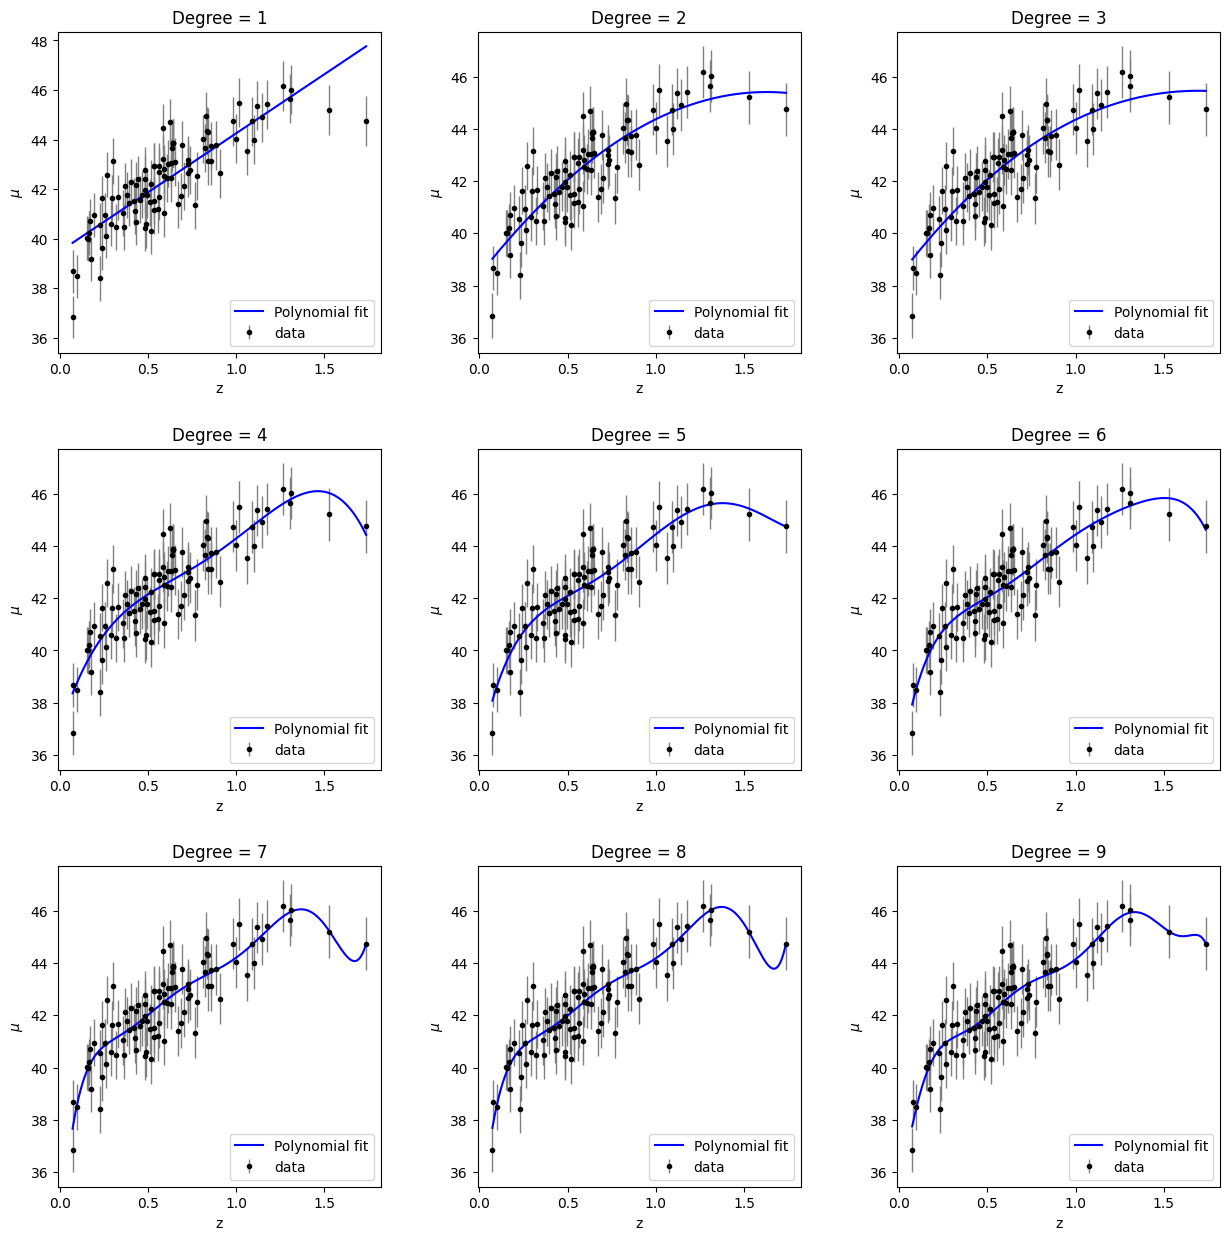

In [13]:
plt.subplots(3, 3, figsize=(15,15))
plt.subplots_adjust(wspace=0.3, hspace=0.3)
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.errorbar(X, y, y_err, fmt='.k', ecolor='gray', lw=1, label='data')
  plt.plot(grid, vec_fit[i], '-b', label='Polynomial fit')
  plt.xlabel("z")
  plt.ylabel("$\mu$")
  plt.title("Degree = {}".format(vec_degree[i]))
  plt.legend(loc='lower right')
plt.show()

**Now let's use cross validation in order to tune hyperparameters such as the degree of the polynomial model**

More regression coefficients improve the ability of the model to fit all the points (reduced bias), but at the expense of model complexity and variance. Of course we can fit a Nth-degree polynomial to N data points, but that would be foolish. We'll determine the best trade-off between bias and variance through cross-validation.

When we increase the complexity of a model, the data points fit the model more and more closely. However, this process does not necessarily result in a better fit to the data. Rather, if the degree is too high, then we are overfitting the data. The model has high variance, meaning that a small change in a training point can change the model dramatically.

Talking about k-fold CV, the procedure is the following:

1. Split the dataset into k+1 subsets: the test set and k CV sets. How you do this is up to you, but typically through random shufflings with equal numbers of points.
2. k models are trained, each time leaving out one of the CV sets in order to measure the CV error.
3. The final training and CV error can be computed using the mean or median of the set of results. The median can be more reliable (but most application use the mean)

In [14]:
from sklearn.model_selection import KFold

In [15]:
# Split the dataset in k-fold CV + test dataset
X_CV, X_test, y_CV, y_test, CV_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.15, random_state=0)
y_err_CV = y_err[CV_idx]
y_err_test = y_err[test_idx]

In [16]:
avg_train_error = []
avg_val_error = []

i = 1
while i < 10:

  # Initialize model
  degree = i
  PRmodel = PolynomialRegression(degree)

  # Define the k-fold splitter
  k = len(y_CV) # leave-one-out k-folding
  kf = KFold(n_splits=k, shuffle=True, random_state=42)

  # Store errors
  train_errors = []
  val_errors = []

  # Loop over the folds
  for train_index, val_index in kf.split(X_CV):

    X_train, X_val = X_CV[train_index], X_CV[val_index]
    y_train, y_val = y_CV[train_index], y_CV[val_index]
    y_err_train, y_err_val = y_err_CV[train_index], y_err_CV[val_index]

    # Train model
    PRmodel.fit(X_train, y_train, y_err_train)

    # Predict
    y_train_pred = PRmodel.predict(X_train)
    y_val_pred = PRmodel.predict(X_val)

    # Compute errors (mean squared error here)
    # train_error = mean_squared_error(y_train, y_train_pred)
    train_error = np.sqrt(np.sum((y_train-y_train_pred)**2)/len(y_train))
    # val_error = mean_squared_error(y_val, y_val_pred)
    val_error = np.sqrt(np.sum((y_val-y_val_pred)**2)/len(y_val))

    # Store
    train_errors.append(train_error)
    val_errors.append(val_error)

  # Final average errors
  avg_train_error.append(np.mean(train_errors))
  avg_val_error.append(np.mean(val_errors))

  i += 1

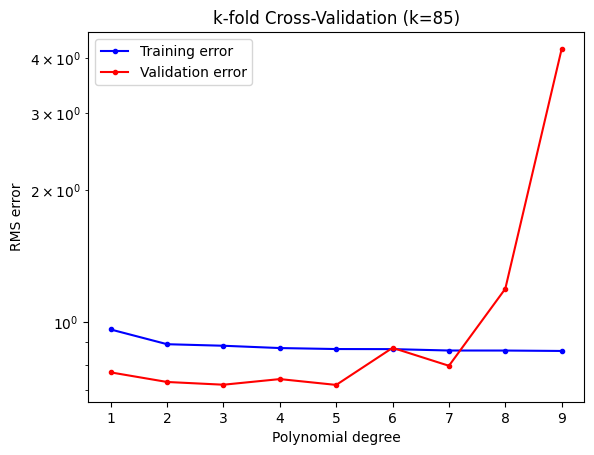

In [17]:
plt.plot(range(1,10), avg_train_error, '.-b', label='Training error')
plt.plot(range(1,10), avg_val_error, '.-r', label='Validation error')
plt.xlabel("Polynomial degree")
plt.ylabel("RMS error")
plt.xticks(range(1,10))
plt.yscale('log')
plt.title("k-fold Cross-Validation (k={:.0f})".format(k))
plt.legend(loc='upper left')
plt.show()

In [18]:
tuned_d = vec_degree[np.where(avg_val_error == np.min(avg_val_error))[0][0]]
print(tuned_d)

5


In [19]:
degree = tuned_d

PRmodel = PolynomialRegression(degree) # fit a tuned_d-degree polynomial
PRmodel.fit(X_CV, y_CV, y_err_CV)

y_pred_test = PRmodel.predict(X_test)

# np.poly1d vuole i coefficienti in ordine decrescente di potenza
coef = PRmodel.coef_
coef = coef[::-1]
print(coef)

grid = np.linspace(X.min(), X.max(), 1000)
p = np.poly1d(coef)
fit = p(grid)

[  8.28954347 -41.36718807  73.50679862 -58.62006606  25.86727687
  36.9246305 ]


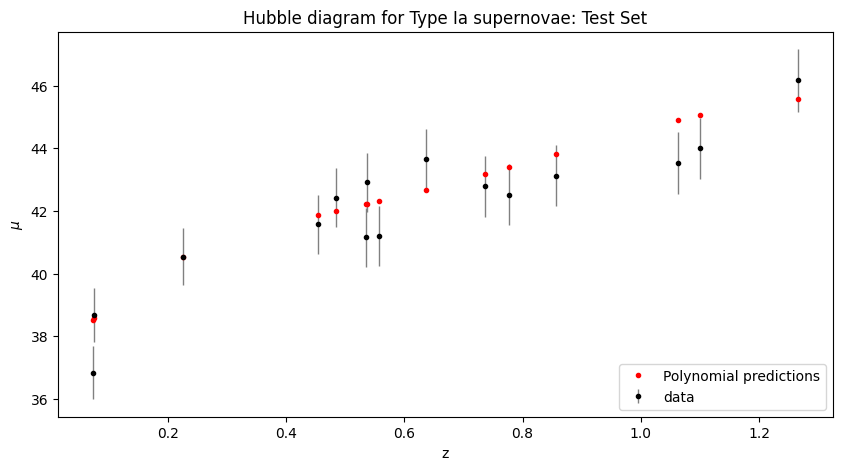

In [20]:
plt.figure(figsize=(10,5))
plt.errorbar(X_test, y_test, y_err_test, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(X_test, y_pred_test, '.r', label='Polynomial predictions')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("Hubble diagram for Type Ia supernovae: Test Set")
plt.legend(loc='lower right')
plt.show()

In [21]:
print(np.array([y_test, y_pred_test]).T)

[[41.57489699 41.86510242]
 [42.5202532  43.38755558]
 [42.425679   41.99828441]
 [43.99305977 45.07118155]
 [43.54157458 44.90772207]
 [46.16398628 45.56356029]
 [42.91403402 42.21982303]
 [40.53942813 40.52436793]
 [43.65443054 42.66971188]
 [41.15578543 42.21798314]
 [38.68032347 38.57761427]
 [41.196534   42.30993839]
 [36.846956   38.53655802]
 [42.78840966 43.16893699]
 [43.12308097 43.82632755]]


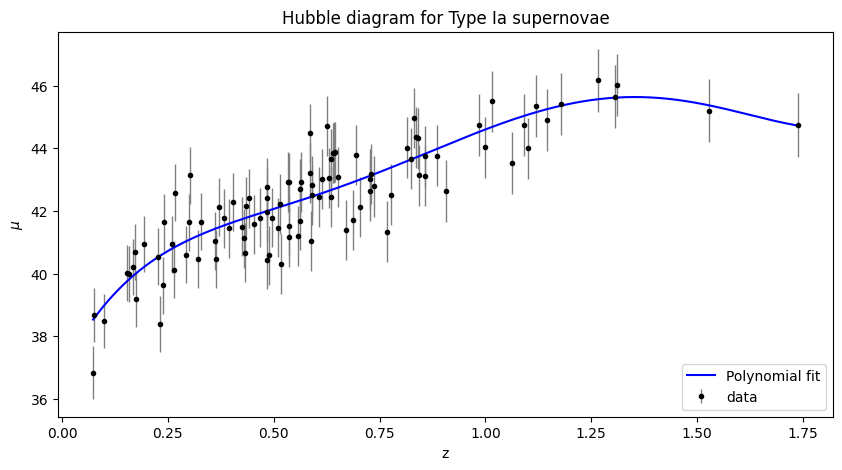

In [22]:
plt.figure(figsize=(10,5))
plt.errorbar(X, y, y_err, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(grid, fit, '-b', label='Polynomial fit')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("Hubble diagram for Type Ia supernovae")
plt.legend(loc='lower right')
plt.show()